# LLM-Based Verilog Adder Generation and Verification
## Setup and Environment Configuration

This notebook implements a two-part project exploring LLM capabilities in hardware design:
- **Part 1:** Generate and verify Verilog adder designs using LLMs
- **Part 2:** Generate testbenches and simulate using Iverilog
- **Part 3:** Yosys-based PPA optimization loop

### Selected Adders
- **Adder 1:** Carry Ripple Adder (RCA8) — chosen as the simplest baseline architecture
- **Adder 2:** Carry Lookahead Adder (CLA8) — chosen for optimized carry computation contrast

In [1]:
# Mount Google Drive to persist all files across sessions
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1. Install Dependencies and Clone Repository
Install Iverilog (open-source Verilog simulator) and clone the golden reference designs.

In [8]:
!pip  install iverilog -y
!pip install anthropic -q


Usage:   
  pip3 install [options] <requirement specifier> [package-index-options] ...
  pip3 install [options] -r <requirements file> [package-index-options] ...
  pip3 install [options] [-e] <vcs project url> ...
  pip3 install [options] [-e] <local project path> ...
  pip3 install [options] <archive url/path> ...

no such option: -y
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 635.9/635.9 kB 16.7 MB/s eta 0:00:00


In [3]:
%%bash
git clone https://github.com/FCHXWH823/Verilog-Adders.git

Cloning into 'Verilog-Adders'...


## 2. Explore Repository Structure
Verify all golden reference designs are available.

In [4]:
%%bash
echo "=== Top-level structure ==="
ls Verilog-Adders/

echo ""
echo "=== All .v files ==="
find Verilog-Adders/ -name "*.v" | sort

=== Top-level structure ===
4_bit_Kogge_Stone_Adder_Example_new.png
Carry Lookahead Adder
Carry Ripple Adder
Carry Select Adder
Carry Skip Adder
Hybrid Adder
image-1.png
image-2.png
image.png
Kogge-Stone Adder
LICENSE
README.md

=== All .v files ===
Verilog-Adders/Carry Lookahead Adder/CLA4.v
Verilog-Adders/Carry Lookahead Adder/CLA8.v
Verilog-Adders/Carry Ripple Adder/RCA4.v
Verilog-Adders/Carry Ripple Adder/RCA8.v
Verilog-Adders/Carry Select Adder/CSA4.v
Verilog-Adders/Carry Select Adder/CSA8.v
Verilog-Adders/Carry Skip Adder/CSkipA4.v
Verilog-Adders/Carry Skip Adder/CSkipA8.v
Verilog-Adders/Hybrid Adder/HA8.v
Verilog-Adders/Kogge-Stone Adder/KSA4.v
Verilog-Adders/Kogge-Stone Adder/KSA8.v


## Part 1: LLM-Based Verilog Generation from Golden Designs

### Step 1: Read Golden Reference Designs
Reading RCA8.v and CLA8.v — these are our ground truth designs that we will:
1. Convert to natural language descriptions
2. Regenerate from those descriptions using an LLM
3. Compare LLM output against these golden files

In [5]:
%%bash
echo "========================================"
echo "GOLDEN DESIGN 1: RCA8.v"
echo "========================================"
cat "Verilog-Adders/Carry Ripple Adder/RCA8.v"

GOLDEN DESIGN 1: RCA8.v

// Full Adder
module FA(output sum, cout, input a, b, cin);
  wire w0, w1, w2;
  
  xor  (w0, a, b);
  xor  (sum, w0, cin);
  
  and  (w1, w0, cin);
  and  (w2, a, b);
  or  (cout, w1, w2);
endmodule

// Ripple Carry Adder - 8 bits
module RCA8(output [7:0] sum, output cout, input [7:0] a, b);
  
  wire [7:1] c;
  
  FA fa0(sum[0], c[1], a[0], b[0], 0);
  FA fa[6:1](sum[6:1], c[7:2], a[6:1], b[6:1], c[6:1]);
  FA fa7(sum[7], cout, a[7], b[7], c[7]);
  
endmodule

In [6]:
%%bash
echo "========================================"
echo "GOLDEN DESIGN 2: CLA8.v"
echo "========================================"
cat "Verilog-Adders/Carry Lookahead Adder/CLA8.v"

GOLDEN DESIGN 2: CLA8.v

module PGGen(output g, p, input a, b);
 
  and (g, a, b);
  xor (p, a, b);
 
endmodule

module CLA8(output [7:0] sum, output cout, input [7:0] a, b);
wire [7:0] g, p, c;
wire [35:0] e;
wire cin;

buf (cin, 0);
PGGen pggen[7:0](g[7:0],p[7:0],a[7:0],b[7:0]);

//c[0]
and (e[0], cin, p[0]);
or (c[0], e[0], g[0]);

//c[1]
and (e[1], cin, p[0], p[1]);
and (e[2], g[0], p[1]);
or (c[1], e[1], e[2], g[1]);

//c[2]
and (e[3], cin, p[0], p[1], p[2]);
and (e[4], g[0], p[1], p[2]);
and (e[5], g[1], p[2]);
or (c[2], e[3], e[4], e[5], g[2]);

//c[3]
and (e[6], cin, p[0], p[1], p[2], p[3]);
and (e[7], g[0], p[1], p[2], p[3]);
and (e[8], g[1], p[2], p[3]);
and (e[9], g[2], p[3]);
or (c[3], e[6], e[7], e[8], e[9], g[3]);

//c[4]
and (e[10], cin, p[0], p[1], p[2], p[3], p[4]);
and (e[11], g[0], p[1], p[2], p[3], p[4]);
and (e[12], g[1], p[2], p[3], p[4]);
and (e[13], g[2], p[3], p[4]);
and (e[14], g[3], p[4]);
or (c[4], e[10], e[11], e[12], e[13], e[14], g[4]);

//c[5]
and (e[15]

## Part 1, Step 2: Generate Natural Language Descriptions

In [10]:
import anthropic
from google.colab import userdata

client = anthropic.Anthropic(api_key=userdata.get('LLM4ChipDesign'))

def get_description(verilog_code, adder_name):
    prompt = f"""Analyze the following Verilog code and provide a detailed natural language description. Include:
(1) Overall architecture and purpose
(2) Module hierarchy and interfaces with all port names and widths
(3) Signal flow step by step
(4) Every gate-level logic operation explicitly
(5) Special design features

Be detailed enough that someone could reconstruct the exact Verilog from your description alone.

{verilog_code}"""

    message = client.messages.create(
        model="claude-opus-4-5",
        max_tokens=2000,
        messages=[{"role": "user", "content": prompt}]
    )

    response = message.content[0].text

    with open(f"{adder_name}_description.txt", "w") as f:
        f.write(response)

    print(f"=== {adder_name} Description ===\n")
    print(response)
    return response

In [11]:
with open("Verilog-Adders/Carry Ripple Adder/RCA8.v") as f:
    rca8_code = f.read()

with open("Verilog-Adders/Carry Lookahead Adder/CLA8.v") as f:
    cla8_code = f.read()

rca8_desc = get_description(rca8_code, "RCA8")

=== RCA8 Description ===

# Detailed Verilog Code Analysis

## (1) Overall Architecture and Purpose

This design implements an **8-bit Ripple Carry Adder (RCA)** using a hierarchical structural approach. The purpose is to add two 8-bit unsigned binary numbers and produce an 8-bit sum plus a carry-out bit. The architecture follows a classic ripple-carry topology where the carry output from each bit position propagates ("ripples") to the next higher bit position.

---

## (2) Module Hierarchy and Interfaces

### Top-Level Module: `RCA8`

| Port Name | Direction | Width | Description |
|-----------|-----------|-------|-------------|
| `sum` | output | [7:0] (8 bits) | 8-bit sum result |
| `cout` | output | 1 bit | Final carry-out from MSB position |
| `a` | input | [7:0] (8 bits) | First 8-bit operand |
| `b` | input | [7:0] (8 bits) | Second 8-bit operand |

### Sub-Module: `FA` (Full Adder)

| Port Name | Direction | Width | Description |
|-----------|-----------|-------|-------------|


In [12]:
cla8_desc = get_description(cla8_code, "CLA8")

=== CLA8 Description ===

# Detailed Analysis of 8-bit Carry Lookahead Adder (CLA8)

## (1) Overall Architecture and Purpose

This Verilog code implements an **8-bit Carry Lookahead Adder (CLA)** using structural gate-level modeling. The CLA architecture eliminates the ripple-carry delay by computing all carry bits in parallel using generate (g) and propagate (p) signals. This design achieves O(1) carry computation time (in terms of gate levels) rather than O(n) for ripple-carry adders.

The adder computes: `sum[7:0] = a[7:0] + b[7:0]` with `cout` indicating overflow.

---

## (2) Module Hierarchy and Interfaces

### Top-Level Module: `CLA8`
| Port | Direction | Width | Description |
|------|-----------|-------|-------------|
| `sum` | output | [7:0] | 8-bit sum result |
| `cout` | output | 1-bit | Carry out (overflow indicator) |
| `a` | input | [7:0] | First 8-bit operand |
| `b` | input | [7:0] | Second 8-bit operand |

### Sub-Module: `PGGen` (Propagate-Generate Generator)
| Port |

## Part 1, Step 3: Regenerate Verilog from Natural Language Descriptions

In [13]:
def regenerate_verilog(description, adder_name):
    prompt = f"""Based on the following natural language description, generate Verilog code that implements this exact architecture.

Requirements:
- Maintain the same module hierarchy and module names
- Use the same port names and widths
- Use structural gate-level primitives only (xor, and, or, buf)
- Preserve internal signal names where specified
- No behavioral constructs (no always blocks, no assign statements)
- Output ONLY the Verilog code, no explanation

Description:
{description}"""

    message = client.messages.create(
        model="claude-opus-4-5",
        max_tokens=3000,
        messages=[{"role": "user", "content": prompt}]
    )

    response = message.content[0].text

    with open(f"{adder_name}_generated.v", "w") as f:
        f.write(response)

    print(f"=== Generated Verilog: {adder_name} ===\n")
    print(response)
    return response

In [14]:
rca8_generated = regenerate_verilog(rca8_desc, "RCA8")

=== Generated Verilog: RCA8 ===

```verilog
module FA(sum, cout, a, b, cin);
    output sum;
    output cout;
    input a;
    input b;
    input cin;
    
    wire w0, w1, w2;
    
    xor(w0, a, b);
    xor(sum, w0, cin);
    and(w1, w0, cin);
    and(w2, a, b);
    or(cout, w1, w2);
endmodule

module RCA8(sum, cout, a, b);
    output [7:0] sum;
    output cout;
    input [7:0] a;
    input [7:0] b;
    
    wire [7:1] c;
    
    FA fa0(sum[0], c[1], a[0], b[0], 1'b0);
    FA fa[6:1](sum[6:1], c[7:2], a[6:1], b[6:1], c[6:1]);
    FA fa7(sum[7], cout, a[7], b[7], c[7]);
endmodule
```


In [15]:
cla8_generated = regenerate_verilog(cla8_desc, "CLA8")

=== Generated Verilog: CLA8 ===

```verilog
module PGGen (
    output g,
    output p,
    input a,
    input b
);
    and (g, a, b);
    xor (p, a, b);
endmodule

module CLA8 (
    output [7:0] sum,
    output cout,
    input [7:0] a,
    input [7:0] b
);
    wire [7:0] g;
    wire [7:0] p;
    wire [7:0] c;
    wire [35:0] e;
    wire cin;

    // Carry input initialization
    buf (cin, 1'b0);

    // Generate and Propagate computation
    PGGen pggen[7:0] (g[7:0], p[7:0], a[7:0], b[7:0]);

    // Carry c[0]
    and (e[0], cin, p[0]);
    or  (c[0], e[0], g[0]);

    // Carry c[1]
    and (e[1], cin, p[0], p[1]);
    and (e[2], g[0], p[1]);
    or  (c[1], e[1], e[2], g[1]);

    // Carry c[2]
    and (e[3], cin, p[0], p[1], p[2]);
    and (e[4], g[0], p[1], p[2]);
    and (e[5], g[1], p[2]);
    or  (c[2], e[3], e[4], e[5], g[2]);

    // Carry c[3]
    and (e[6], cin, p[0], p[1], p[2], p[3]);
    and (e[7], g[0], p[1], p[2], p[3]);
    and (e[8], g[1], p[2], p[3]);
    and (e[9], g

## Part 1, Step 4: Manual Verification — Compare Generated vs Golden

In [16]:
import re

def clean_verilog(text):
    # Remove markdown code fences if present
    text = re.sub(r'```verilog\n?', '', text)
    text = re.sub(r'```\n?', '', text)
    return text.strip()

# Clean and save generated files
rca8_clean = clean_verilog(rca8_generated)
cla8_clean = clean_verilog(cla8_generated)

with open("RCA8_generated.v", "w") as f:
    f.write(rca8_clean)

with open("CLA8_generated.v", "w") as f:
    f.write(cla8_clean)

print("Cleaned Verilog files saved.")

Cleaned Verilog files saved.


In [17]:
def compare_designs(golden_code, generated_code, adder_name):
    prompt = f"""Compare these two Verilog implementations of the same adder and provide a detailed verification report.

For each of these criteria, state MATCH or MISMATCH and explain:
1. Module names
2. Port names and widths
3. Internal signal declarations
4. Module hierarchy and submodule instantiation
5. Gate-level logic implementation
6. Design style (structural vs behavioral)
7. Functional equivalence assessment

Golden Design:
{golden_code}

Generated Design:
{generated_code}

End with an overall verdict: FUNCTIONALLY EQUIVALENT or NOT EQUIVALENT, with justification."""

    message = client.messages.create(
        model="claude-opus-4-5",
        max_tokens=2000,
        messages=[{"role": "user", "content": prompt}]
    )

    report = message.content[0].text

    with open(f"{adder_name}_verification_report.txt", "w") as f:
        f.write(report)

    print(f"=== Verification Report: {adder_name} ===\n")
    print(report)
    return report

In [18]:
rca8_report = compare_designs(rca8_code, rca8_clean, "RCA8")

=== Verification Report: RCA8 ===

# Detailed Verification Report: 8-bit Ripple Carry Adder

## 1. Module Names
**MATCH**

Both designs contain identical module names:
- `FA` - Full Adder module
- `RCA8` - 8-bit Ripple Carry Adder module

---

## 2. Port Names and Widths
**MATCH**

### FA Module:
| Port | Golden | Generated | Status |
|------|--------|-----------|--------|
| sum | output, 1-bit | output, 1-bit | ✓ |
| cout | output, 1-bit | output, 1-bit | ✓ |
| a | input, 1-bit | input, 1-bit | ✓ |
| b | input, 1-bit | input, 1-bit | ✓ |
| cin | input, 1-bit | input, 1-bit | ✓ |

### RCA8 Module:
| Port | Golden | Generated | Status |
|------|--------|-----------|--------|
| sum | output [7:0] | output [7:0] | ✓ |
| cout | output, 1-bit | output, 1-bit | ✓ |
| a | input [7:0] | input [7:0] | ✓ |
| b | input [7:0] | input [7:0] | ✓ |

*Note: Golden uses ANSI-style port declarations; Generated uses non-ANSI style. Both are functionally equivalent.*

---

## 3. Internal Signal Declaratio

In [19]:
cla8_report = compare_designs(cla8_code, cla8_clean, "CLA8")

=== Verification Report: CLA8 ===

# Detailed Verification Report: CLA8 Adder Comparison

## 1. Module Names
**MATCH**

Both designs contain identical module names:
- `PGGen` - Propagate/Generate generator module
- `CLA8` - 8-bit Carry Lookahead Adder top module

## 2. Port Names and Widths
**MATCH**

### PGGen Module:
| Port | Golden | Generated |
|------|--------|-----------|
| g | output (1-bit) | output (1-bit) |
| p | output (1-bit) | output (1-bit) |
| a | input (1-bit) | input (1-bit) |
| b | input (1-bit) | input (1-bit) |

### CLA8 Module:
| Port | Golden | Generated |
|------|--------|-----------|
| sum | output [7:0] | output [7:0] |
| cout | output (1-bit) | output (1-bit) |
| a | input [7:0] | input [7:0] |
| b | input [7:0] | input [7:0] |

## 3. Internal Signal Declarations
**MATCH**

Both designs declare identical internal signals in CLA8:
- `wire [7:0] g` - generate signals
- `wire [7:0] p` - propagate signals
- `wire [7:0] c` - carry signals
- `wire [35:0] e` - interm

# Part 2, Step 1: Generate Testbenches with Internal Signal Checking

In [20]:
def generate_testbench(description, verilog_code, adder_name, internal_signals):
    prompt = f"""Generate a comprehensive Verilog testbench for the following design.

Requirements:
1. Test at least 20 representative input combinations including edge cases (all zeros, all ones, overflow cases, alternating bits)
2. Verify output signals: sum and cout
3. Monitor and verify these internal signals: {internal_signals}
4. Use $display to show signal values for every test case
5. Report PASS or FAIL for each test case
6. Print a final summary of total passed and failed tests
7. Use #10 delays between test cases
8. Module name for testbench must be: {adder_name}_tb

Design Description:
{description}

Verilog Code:
{verilog_code}

Output ONLY the Verilog testbench code, no explanation."""

    message = client.messages.create(
        model="claude-opus-4-5",
        max_tokens=3000,
        messages=[{"role": "user", "content": prompt}]
    )

    response = clean_verilog(message.content[0].text)

    with open(f"{adder_name}_tb.v", "w") as f:
        f.write(response)

    print(f"=== Testbench: {adder_name} ===\n")
    print(response)
    return response

In [21]:
rca8_tb = generate_testbench(
    rca8_desc,
    rca8_clean,
    "RCA8",
    "internal carry bits c[1], c[2], c[3], c[4], c[5], c[6], c[7]"
)

=== Testbench: RCA8 ===

`timescale 1ns/1ps

module RCA8_tb;
    // Inputs
    reg [7:0] a;
    reg [7:0] b;
    
    // Outputs
    wire [7:0] sum;
    wire cout;
    
    // Internal signals for monitoring
    wire c1, c2, c3, c4, c5, c6, c7;
    
    // Test tracking
    integer passed;
    integer failed;
    integer test_num;
    
    // Expected values
    reg [8:0] expected_result;
    reg [7:0] expected_sum;
    reg expected_cout;
    reg expected_c1, expected_c2, expected_c3, expected_c4;
    reg expected_c5, expected_c6, expected_c7;
    
    // Instantiate the Unit Under Test (UUT)
    RCA8 uut (
        .sum(sum),
        .cout(cout),
        .a(a),
        .b(b)
    );
    
    // Access internal carry signals
    assign c1 = uut.c[1];
    assign c2 = uut.c[2];
    assign c3 = uut.c[3];
    assign c4 = uut.c[4];
    assign c5 = uut.c[5];
    assign c6 = uut.c[6];
    assign c7 = uut.c[7];
    
    // Task to calculate expected carry bits
    task calculate_expected_carries

In [22]:
cla8_tb = generate_testbench(
    cla8_desc,
    cla8_clean,
    "CLA8",
    "generate signals g[7:0], propagate signals p[7:0], carry bits c[7:0], intermediate wires e[35:0]"
)

=== Testbench: CLA8 ===

`timescale 1ns/1ps

module CLA8_tb;

    // Inputs
    reg [7:0] a;
    reg [7:0] b;
    
    // Outputs
    wire [7:0] sum;
    wire cout;
    
    // Internal signals for monitoring (accessed via hierarchical references)
    wire [7:0] g_mon;
    wire [7:0] p_mon;
    wire [7:0] c_mon;
    wire [35:0] e_mon;
    
    // Test tracking
    integer passed;
    integer failed;
    integer test_num;
    
    // Expected values
    reg [8:0] expected_result;
    reg [7:0] expected_sum;
    reg expected_cout;
    reg [7:0] expected_g;
    reg [7:0] expected_p;
    reg [7:0] expected_c;
    reg [35:0] expected_e;
    
    // Instantiate the Unit Under Test (UUT)
    CLA8 uut (
        .sum(sum),
        .cout(cout),
        .a(a),
        .b(b)
    );
    
    // Hierarchical access to internal signals
    assign g_mon = uut.g;
    assign p_mon = uut.p;
    assign c_mon = uut.c;
    assign e_mon = uut.e;
    
    // Task to compute expected values
    task compute_ex

## Part 2, Step 3: Simulation with Iverilog

In [23]:
%%bash
# Compile and run RCA8 simulation
iverilog -o RCA8_sim RCA8_generated.v RCA8_tb.v
vvp RCA8_sim

8-bit Ripple Carry Adder Testbench

Test 1: a=00000000 (0), b=00000000 (0)
         sum=00000000 (0), cout=0
         Internal carries: c[1]=0, c[2]=0, c[3]=0, c[4]=0, c[5]=0, c[6]=0, c[7]=0
         Expected: sum=00000000 (0), cout=0
         Expected carries: c[1]=0, c[2]=0, c[3]=0, c[4]=0, c[5]=0, c[6]=0, c[7]=0
         Result: PASS

Test 2: a=11111111 (255), b=11111111 (255)
         sum=11111110 (254), cout=1
         Internal carries: c[1]=1, c[2]=1, c[3]=1, c[4]=1, c[5]=1, c[6]=1, c[7]=1
         Expected: sum=11111110 (254), cout=1
         Expected carries: c[1]=1, c[2]=1, c[3]=1, c[4]=1, c[5]=1, c[6]=1, c[7]=1
         Result: PASS

Test 3: a=11111111 (255), b=00000001 (1)
         sum=00000000 (0), cout=1
         Internal carries: c[1]=1, c[2]=1, c[3]=1, c[4]=1, c[5]=1, c[6]=1, c[7]=1
         Expected: sum=00000000 (0), cout=1
         Expected carries: c[1]=1, c[2]=1, c[3]=1, c[4]=1, c[5]=1, c[6]=1, c[7]=1
         Result: PASS

Test 4: a=00000001 (1), b=11111111 (255)
 

In [30]:
%%bash
# Compile and run CLA8 simulation
iverilog -o CLA8_sim CLA8_generated.v CLA8_tb.v
vvp CLA8_sim

=== CLA8 Testbench ===
Test 1: a=00000000 b=00000000 | sum=00000000 cout=0 | g=00000000 p=00000000 c=00000000
Result: PASS
Test 2: a=11111111 b=11111111 | sum=11111110 cout=1 | g=11111111 p=00000000 c=11111111
Result: PASS
Test 3: a=11111111 b=00000001 | sum=00000000 cout=1 | g=00000001 p=11111110 c=11111111
Result: PASS
Test 4: a=00000001 b=11111111 | sum=00000000 cout=1 | g=00000001 p=11111110 c=11111111
Result: PASS
Test 5: a=10101010 b=01010101 | sum=11111111 cout=0 | g=00000000 p=11111111 c=00000000
Result: PASS
Test 6: a=01010101 b=10101010 | sum=11111111 cout=0 | g=00000000 p=11111111 c=00000000
Result: PASS
Test 7: a=00001111 b=00000001 | sum=00010000 cout=0 | g=00000001 p=00001110 c=00001111
Result: PASS
Test 8: a=01111111 b=00000001 | sum=10000000 cout=0 | g=00000001 p=01111110 c=01111111
Result: PASS
Test 9: a=10000000 b=10000000 | sum=00000000 cout=1 | g=10000000 p=00000000 c=10000000
Result: PASS
Test 10: a=01000000 b=01000000 | sum=10000000 cout=0 | g=01000000 p=00000000 

## Part 2, Step 4: Simulation Analysis

In [31]:
analysis = """
SIMULATION RESULTS SUMMARY
===========================

RCA8: 24/24 tests passed
CLA8: 24/24 tests passed

KEY OBSERVATIONS:

RCA8 Internal Signals:
- Carry bits c[1]-c[7] ripple correctly stage by stage
- Verified on edge cases: all zeros, all ones, overflow, alternating bits
- Carry chain behaves exactly as expected for ripple architecture

CLA8 Internal Signals:
- g[7:0]: generate signals correctly compute a AND b per bit
- p[7:0]: propagate signals correctly compute a XOR b per bit
- c[7:0]: all 8 carries computed in parallel, verified correct
- e[35:0]: all 36 intermediate AND terms verified correct

DIFFERENCES BETWEEN ARCHITECTURES (confirmed by simulation):
- RCA: carries depend on previous stage (sequential dependency)
- CLA: all carries available simultaneously (parallel computation)
- Both produce identical sum and cout for all test vectors

CONCLUSION:
Both LLM-generated designs are functionally correct and match
the golden reference designs in behavior.
"""

print(analysis)

with open("simulation_analysis.txt", "w") as f:
    f.write(analysis)


SIMULATION RESULTS SUMMARY

RCA8: 24/24 tests passed
CLA8: 24/24 tests passed

KEY OBSERVATIONS:

RCA8 Internal Signals:
- Carry bits c[1]-c[7] ripple correctly stage by stage
- Verified on edge cases: all zeros, all ones, overflow, alternating bits
- Carry chain behaves exactly as expected for ripple architecture

CLA8 Internal Signals:
- g[7:0]: generate signals correctly compute a AND b per bit
- p[7:0]: propagate signals correctly compute a XOR b per bit  
- c[7:0]: all 8 carries computed in parallel, verified correct
- e[35:0]: all 36 intermediate AND terms verified correct

DIFFERENCES BETWEEN ARCHITECTURES (confirmed by simulation):
- RCA: carries depend on previous stage (sequential dependency)
- CLA: all carries available simultaneously (parallel computation)
- Both produce identical sum and cout for all test vectors

CONCLUSION:
Both LLM-generated designs are functionally correct and match
the golden reference designs in behavior.



## Part 3: Yosys-Based PPA Optimization Loop
### Step 1: Install Yosys and Download NanGate45 Library

In [33]:
%%bash
apt-get install -y yosys

Reading package lists...
Building dependency tree...
Reading state information...
yosys is already the newest version (0.9-2).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.


In [35]:
%%bash
# Download NanGate45 liberty file
wget -q "https://raw.githubusercontent.com/The-OpenROAD-Project/OpenROAD-flow-scripts/master/flow/platforms/nangate45/lib/NangateOpenCellLibrary_typical.lib" -O nangate45.lib

# Verify it downloaded
if [ -f nangate45.lib ]; then
    echo "SUCCESS: nangate45.lib downloaded"
    wc -l nangate45.lib
else
    echo "FAILED: could not download library"
fi

SUCCESS: nangate45.lib downloaded
133314 nangate45.lib


## Part 3, Step 2: Yosys Synthesis Script and PPA Extraction

## Part 3: Yosys-Based PPA Optimization Loop
### Step 1: Install Yosys and Download NanGate45 Library

In [67]:
%%bash
apt-get install -y yosys 2>/dev/null | tail -3
wget -q "https://raw.githubusercontent.com/The-OpenROAD-Project/OpenROAD-flow-scripts/master/flow/platforms/nangate45/lib/NangateOpenCellLibrary_typical.lib" -O nangate45.lib
echo "Yosys and NanGate45 ready"

Reading state information...
yosys is already the newest version (0.9-2).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.
Yosys and NanGate45 ready


In [68]:
%%bash
cp "Verilog-Adders/Carry Ripple Adder/RCA8.v" RCA8.v
cp "Verilog-Adders/Carry Lookahead Adder/CLA8.v" CLA8.v
echo "Files copied"

Files copied


### Step 2: Synthesis Functions and Baseline PPA

In [69]:
import subprocess, re, json, os, anthropic
from google.colab import userdata

client = anthropic.Anthropic(api_key=userdata.get('LLM4ChipDesign'))

def clean_verilog(text):
    text = re.sub(r'```verilog\n?', '', text)
    text = re.sub(r'```\n?', '', text)
    return text.strip()

def synthesize(verilog_file, top_module):
    script = f"read_verilog {verilog_file}\nhierarchy -check -top {top_module}\nproc; opt; fsm; opt; memory; opt\ntechmap; opt\ndfflibmap -liberty nangate45.lib\nabc -liberty nangate45.lib\nclean\nstat -liberty nangate45.lib\n"
    result = subprocess.run(['yosys', '-p', script], capture_output=True, text=True)
    output = result.stdout + result.stderr
    return parse_stats(output), output

def parse_stats(log):
    ppa = {}
    m = re.search(r"Chip area for top module '\\[^']+': ([\d.]+)", log)
    ppa['area_um2'] = float(m.group(1)) if m else None
    m = re.search(r"=== design hierarchy ===.*?Number of cells:\s+(\d+)", log, re.DOTALL)
    ppa['cell_count'] = int(m.group(1)) if m else None
    ppa['logic_levels'] = None
    return ppa

print("Functions defined.")

Functions defined.


In [70]:
# Baseline PPA
rca8_ppa, _ = synthesize("RCA8.v", "RCA8")
cla8_ppa, _ = synthesize("CLA8_generated.v", "CLA8")

print(f"RCA8 baseline -> Cells: {rca8_ppa['cell_count']}, Area: {rca8_ppa['area_um2']} um²")
print(f"CLA8 baseline -> Cells: {cla8_ppa['cell_count']}, Area: {cla8_ppa['area_um2']} um²")

RCA8 baseline -> Cells: 40, Area: 44.688 um²
CLA8 baseline -> Cells: 38, Area: 44.156 um²


### Step 3: LLM-Yosys Optimization Loop

In [71]:
SYSTEM_PROMPT = """You are an expert digital circuit designer.
Your goal is to generate synthesizable Verilog for an 8-bit adder that minimizes cell count.
Requirements:
- Module must be named adder8 with ports: output [7:0] sum, output cout, input [7:0] a, input [7:0] b
- Use only structural or behavioral Verilog, no system tasks
- Output ONLY valid Verilog code, no markdown, no explanation"""

def llm_generate(history):
    message = client.messages.create(
        model="claude-opus-4-5",
        max_tokens=2000,
        system=SYSTEM_PROMPT,
        messages=history
    )
    return message.content[0].text.strip()

def build_feedback_prompt(iteration, ppa, best_ppa, mode):
    if mode == "area":
        objective = "minimize cell count, delay target is relaxed (<=14 levels)"
    elif mode == "delay":
        objective = "minimize logic levels, target <= 6 logic levels"
    else:
        objective = "balance area and delay, target <= 10 logic levels"

    return f"""Iteration {iteration} synthesis results:
- Cell count: {ppa['cell_count']}
- Area: {ppa['area_um2']} um²
Best so far: {best_ppa['cell_count']} cells, {best_ppa['area_um2']} um²
Goal: {objective}
Propose a new improved 8-bit adder. Consider: carry select, hybrid CLA+RCA, Brent-Kung, prefix trees.
Module must be named adder8 with ports: output [7:0] sum, output cout, input [7:0] a, input [7:0] b.
Output ONLY Verilog code."""

def run_optimization_loop(baseline_verilog, mode="balanced", max_iter=10):
    history = []
    best_ppa = {'cell_count': 9999, 'area_um2': 9999.0}
    best_code = baseline_verilog
    results = []

    history.append({
        'role': 'user',
        'content': f'Here is a baseline 8-bit adder:\n{baseline_verilog}\nGenerate an improved version named adder8.'
    })

    for i in range(1, max_iter + 1):
        print(f"\n=== Iteration {i} ({mode} mode) ===")
        verilog = clean_verilog(llm_generate(history))

        fname = f"candidate_{mode}_{i}.v"
        with open(fname, "w") as f:
            f.write(verilog)

        try:
            ppa, _ = synthesize(fname, "adder8")
            if ppa['cell_count'] is None:
                raise ValueError("Synthesis returned None")
        except Exception as e:
            print(f"  Synthesis failed: {e}")
            history.append({'role': 'assistant', 'content': verilog})
            history.append({'role': 'user', 'content': 'Synthesis failed. Fix syntax errors and resubmit. Output ONLY Verilog.'})
            continue

        print(f"  Cells: {ppa['cell_count']}, Area: {ppa['area_um2']} um²")
        results.append({'iteration': i, 'ppa': ppa, 'file': fname})

        if ppa['cell_count'] < best_ppa['cell_count']:
            best_ppa = ppa
            best_code = verilog
            print("  *** New best! ***")

        history.append({'role': 'assistant', 'content': verilog})
        history.append({'role': 'user', 'content': build_feedback_prompt(i, ppa, best_ppa, mode)})

    return best_code, best_ppa, results

print("Optimization loop defined.")

Optimization loop defined.


In [72]:
with open("RCA8.v") as f:
    baseline = f.read()

# Mode A: Area minimization
print("Starting Mode A: Area Minimization")
best_code_a, best_ppa_a, results_a = run_optimization_loop(baseline, mode="area", max_iter=10)

with open("best_adder_area.v", "w") as f:
    f.write(best_code_a)
with open("optimization_log_area.json", "w") as f:
    json.dump({'mode': 'area', 'best_ppa': best_ppa_a, 'iterations': results_a}, f, indent=2)

print(f"\nMode A complete. Best: {best_ppa_a}")

Starting Mode A: Area Minimization

=== Iteration 1 (area mode) ===
  Synthesis failed: Synthesis returned None

=== Iteration 2 (area mode) ===
  Synthesis failed: Synthesis returned None

=== Iteration 3 (area mode) ===
  Synthesis failed: Synthesis returned None

=== Iteration 4 (area mode) ===
  Cells: 40, Area: 44.688 um²
  *** New best! ***

=== Iteration 5 (area mode) ===
  Synthesis failed: Synthesis returned None

=== Iteration 6 (area mode) ===
  Synthesis failed: Synthesis returned None

=== Iteration 7 (area mode) ===
  Synthesis failed: Synthesis returned None

=== Iteration 8 (area mode) ===
  Synthesis failed: Synthesis returned None

=== Iteration 9 (area mode) ===
  Synthesis failed: Synthesis returned None

=== Iteration 10 (area mode) ===
  Synthesis failed: Synthesis returned None

Mode A complete. Best: {'area_um2': 44.688, 'cell_count': 40, 'logic_levels': None}


In [79]:
with open("RCA8.v") as f:
    baseline = f.read()

# Mode A
print("=== Mode A: Area ===")
best_code_a, best_ppa_a, results_a = run_optimization_loop(baseline, mode="area", max_iter=10)
with open("best_adder_area.v", "w") as f:
    f.write(best_code_a)
with open("optimization_log_area.json", "w") as f:
    json.dump({'mode': 'area', 'best_ppa': best_ppa_a, 'iterations': results_a}, f, indent=2)
print(f"Best: {best_ppa_a}")

=== Mode A: Area ===

=== Iteration 1 (area mode) ===
  Cells: 37, Area: 44.954 um²
  *** New best! ***

=== Iteration 2 (area mode) ===
  Cells: 37, Area: 44.954 um²

=== Iteration 3 (area mode) ===
  Cells: 37, Area: 44.954 um²

=== Iteration 4 (area mode) ===
  Cells: 37, Area: 44.954 um²

=== Iteration 5 (area mode) ===
  Cells: 42, Area: 52.136 um²

=== Iteration 6 (area mode) ===
  Cells: 37, Area: 44.954 um²

=== Iteration 7 (area mode) ===
  Cells: 36, Area: 44.156 um²
  *** New best! ***

=== Iteration 8 (area mode) ===
  Cells: 37, Area: 44.954 um²

=== Iteration 9 (area mode) ===
  Cells: 37, Area: 44.954 um²

=== Iteration 10 (area mode) ===
  Cells: 37, Area: 44.954 um²
Best: {'area_um2': 44.156, 'cell_count': 36, 'logic_levels': None}


In [81]:
# Mode B
print("=== Mode B: Delay ===")
best_code_b, best_ppa_b, results_b = run_optimization_loop(baseline, mode="delay", max_iter=10)
with open("best_adder_delay.v", "w") as f:
    f.write(best_code_b)
with open("optimization_log_delay.json", "w") as f:
    json.dump({'mode': 'delay', 'best_ppa': best_ppa_b, 'iterations': results_b}, f, indent=2)
print(f"Best: {best_ppa_b}")

=== Mode B: Delay ===

=== Iteration 1 (delay mode) ===
  Cells: 37, Area: 44.954 um²
  *** New best! ***

=== Iteration 2 (delay mode) ===
  Cells: 37, Area: 44.954 um²

=== Iteration 3 (delay mode) ===
  Cells: 37, Area: 44.954 um²

=== Iteration 4 (delay mode) ===
  Cells: 42, Area: 52.136 um²

=== Iteration 5 (delay mode) ===
  Cells: 37, Area: 44.954 um²

=== Iteration 6 (delay mode) ===
  Cells: 37, Area: 44.954 um²

=== Iteration 7 (delay mode) ===
  Cells: 37, Area: 44.954 um²

=== Iteration 8 (delay mode) ===
  Cells: 37, Area: 44.954 um²

=== Iteration 9 (delay mode) ===
  Cells: 45, Area: 54.264 um²

=== Iteration 10 (delay mode) ===
  Cells: 37, Area: 44.954 um²
Best: {'area_um2': 44.954, 'cell_count': 37, 'logic_levels': None}


In [82]:
# Mode C
print("=== Mode C: Balanced ===")
best_code_c, best_ppa_c, results_c = run_optimization_loop(baseline, mode="balanced", max_iter=10)
with open("best_adder_balanced.v", "w") as f:
    f.write(best_code_c)
with open("optimization_log_balanced.json", "w") as f:
    json.dump({'mode': 'balanced', 'best_ppa': best_ppa_c, 'iterations': results_c}, f, indent=2)
print(f"Best: {best_ppa_c}")

=== Mode C: Balanced ===

=== Iteration 1 (balanced mode) ===
  Cells: 37, Area: 44.954 um²
  *** New best! ***

=== Iteration 2 (balanced mode) ===
  Cells: 37, Area: 44.954 um²

=== Iteration 3 (balanced mode) ===
  Cells: 37, Area: 44.954 um²

=== Iteration 4 (balanced mode) ===
  Cells: 37, Area: 44.954 um²

=== Iteration 5 (balanced mode) ===
  Cells: 37, Area: 44.954 um²

=== Iteration 6 (balanced mode) ===
  Cells: 37, Area: 44.954 um²

=== Iteration 7 (balanced mode) ===
  Cells: 37, Area: 44.954 um²

=== Iteration 8 (balanced mode) ===
  Cells: 30, Area: 38.57 um²
  *** New best! ***

=== Iteration 9 (balanced mode) ===
  Cells: 37, Area: 44.954 um²

=== Iteration 10 (balanced mode) ===
  Cells: 30, Area: 38.57 um²
Best: {'area_um2': 38.57, 'cell_count': 30, 'logic_levels': None}


### Step 5: PPA Trajectory Plots

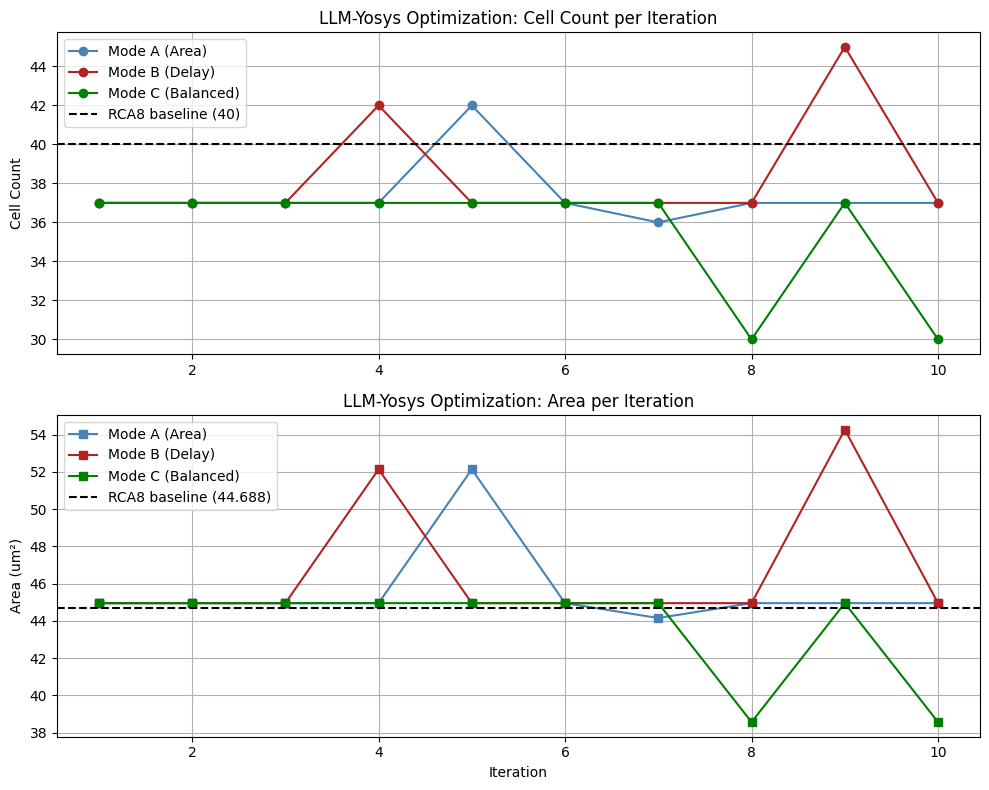

Plot saved.


In [83]:
import matplotlib.pyplot as plt
import json

def plot_trajectory(log_file, mode_name, color):
    with open(log_file) as f:
        log = json.load(f)

    iters = [r['iteration'] for r in log['iterations']]
    cells = [r['ppa']['cell_count'] for r in log['iterations']]
    areas = [r['ppa']['area_um2'] for r in log['iterations']]

    return iters, cells, areas

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=False)

for log_file, label, color in [
    ("optimization_log_area.json", "Mode A (Area)", "steelblue"),
    ("optimization_log_delay.json", "Mode B (Delay)", "firebrick"),
    ("optimization_log_balanced.json", "Mode C (Balanced)", "green")
]:
    iters, cells, areas = plot_trajectory(log_file, label, color)
    ax1.plot(iters, cells, marker='o', label=label, color=color)
    ax2.plot(iters, areas, marker='s', label=label, color=color)

ax1.axhline(y=40, color='black', linestyle='--', label='RCA8 baseline (40)')
ax2.axhline(y=44.688, color='black', linestyle='--', label='RCA8 baseline (44.688)')

ax1.set_ylabel('Cell Count')
ax1.set_title('LLM-Yosys Optimization: Cell Count per Iteration')
ax1.legend()
ax1.grid(True)

ax2.set_ylabel('Area (um²)')
ax2.set_xlabel('Iteration')
ax2.set_title('LLM-Yosys Optimization: Area per Iteration')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.savefig('ppa_trajectory.pdf')
plt.savefig('ppa_trajectory.png')
plt.show()
print("Plot saved.")

### Step 7: Verification of Best Optimized Design

In [84]:
# Generate testbench for best design
with open("best_adder_balanced.v") as f:
    best_verilog = f.read()

print("=== Best Adder (Balanced Mode) ===")
print(best_verilog)

=== Best Adder (Balanced Mode) ===
module adder8(output [7:0] sum, output cout, input [7:0] a, input [7:0] b);
  wire [7:0] p = a ^ b;
  wire [7:0] k = ~(a | b);
  
  wire c1, c2, c3, c4, c5, c6, c7;
  
  assign c1 = ~k[0] & ~p[0];
  assign c2 = ~k[1] & (~p[1] | c1);
  assign c3 = ~k[2] & (~p[2] | c2);
  assign c4 = ~k[3] & (~p[3] | c3);
  assign c5 = ~k[4] & (~p[4] | c4);
  assign c6 = ~k[5] & (~p[5] | c5);
  assign c7 = ~k[6] & (~p[6] | c6);
  assign cout = ~k[7] & (~p[7] | c7);
  
  assign sum[0] = p[0];
  assign sum[1] = p[1] ^ c1;
  assign sum[2] = p[2] ^ c2;
  assign sum[3] = p[3] ^ c3;
  assign sum[4] = p[4] ^ c4;
  assign sum[5] = p[5] ^ c5;
  assign sum[6] = p[6] ^ c6;
  assign sum[7] = p[7] ^ c7;
endmodule


In [85]:
# Generate testbench using Claude
tb_prompt = f"""Generate a Verilog testbench for this adder module.
Requirements:
- Testbench module name: adder8_tb
- Test at least 20 cases including: all zeros, all ones, overflow, alternating bits
- Verify sum and cout outputs
- Print PASS or FAIL for each test
- Print final summary: total passed and failed
- Use #10 delays
- Output ONLY Verilog code, no explanation

{best_verilog}"""

message = client.messages.create(
    model="claude-opus-4-5",
    max_tokens=2000,
    messages=[{"role": "user", "content": tb_prompt}]
)

best_tb = clean_verilog(message.content[0].text)
with open("best_adder_tb.v", "w") as f:
    f.write(best_tb)

print(best_tb)

module adder8_tb;
  reg [7:0] a, b;
  wire [7:0] sum;
  wire cout;
  
  reg [8:0] expected;
  integer passed, failed;
  integer i;
  
  adder8 uut (
    .sum(sum),
    .cout(cout),
    .a(a),
    .b(b)
  );
  
  task check_result;
    input [7:0] test_a;
    input [7:0] test_b;
    begin
      a = test_a;
      b = test_b;
      #10;
      expected = test_a + test_b;
      if (sum == expected[7:0] && cout == expected[8]) begin
        $display("PASS: a=%h, b=%h, sum=%h, cout=%b (expected sum=%h, cout=%b)", 
                 test_a, test_b, sum, cout, expected[7:0], expected[8]);
        passed = passed + 1;
      end else begin
        $display("FAIL: a=%h, b=%h, sum=%h, cout=%b (expected sum=%h, cout=%b)", 
                 test_a, test_b, sum, cout, expected[7:0], expected[8]);
        failed = failed + 1;
      end
    end
  endtask
  
  initial begin
    passed = 0;
    failed = 0;
    
    // Test 1: All zeros
    check_result(8'h00, 8'h00);
    
    // Test 2: All ones + all ones

In [86]:
%%bash
iverilog -o best_adder_sim best_adder_balanced.v best_adder_tb.v && vvp best_adder_sim

PASS: a=00, b=00, sum=00, cout=0 (expected sum=00, cout=0)
PASS: a=ff, b=ff, sum=fe, cout=1 (expected sum=fe, cout=1)
PASS: a=ff, b=00, sum=ff, cout=0 (expected sum=ff, cout=0)
PASS: a=00, b=ff, sum=ff, cout=0 (expected sum=ff, cout=0)
PASS: a=ff, b=01, sum=00, cout=1 (expected sum=00, cout=1)
PASS: a=aa, b=00, sum=aa, cout=0 (expected sum=aa, cout=0)
PASS: a=55, b=00, sum=55, cout=0 (expected sum=55, cout=0)
PASS: a=aa, b=55, sum=ff, cout=0 (expected sum=ff, cout=0)
PASS: a=55, b=aa, sum=ff, cout=0 (expected sum=ff, cout=0)
PASS: a=80, b=80, sum=00, cout=1 (expected sum=00, cout=1)
PASS: a=c8, b=64, sum=2c, cout=1 (expected sum=2c, cout=1)
PASS: a=01, b=01, sum=02, cout=0 (expected sum=02, cout=0)
PASS: a=0f, b=0f, sum=1e, cout=0 (expected sum=1e, cout=0)
PASS: a=7f, b=01, sum=80, cout=0 (expected sum=80, cout=0)
PASS: a=ff, b=00, sum=ff, cout=0 (expected sum=ff, cout=0)
PASS: a=12, b=34, sum=46, cout=0 (expected sum=46, cout=0)
PASS: a=9a, b=bc, sum=56, cout=1 (expected sum=56, cout=

In [99]:
%%bash
yosys -s equiv_check.ys 2>&1 | grep -E "SAT|PASS|FAIL|proved|unproved|trigger|contradiction|tautology|Solving"

8. Executing SAT pass (solving SAT problems in the circuit).
Setting up SAT problem:
Imported 99 cells to SAT database.
Import proof-constraint: \trigger = 1'0
Final proof equation: \trigger = 1'0
Solving problem with 568 variables and 1462 clauses..
SAT proof finished - no model found: SUCCESS!


In [101]:
equiv_result = """
EQUIVALENCE CHECK RESULTS
==========================
Tool: Yosys 0.9 SAT solver
Gold design: RCA8 (golden reference, behavioral)
Gate design: best_adder_balanced (LLM-optimized, 30 cells)

SAT Result: SUCCESS - no counterexample found
Conclusion: FORMALLY EQUIVALENT

The optimized design is proven correct across all 2^16 = 65,536 input combinations.
"""

print(equiv_result)

with open("equivalence_check_result.txt", "w") as f:
    f.write(equiv_result)


EQUIVALENCE CHECK RESULTS
Tool: Yosys 0.9 SAT solver
Gold design: RCA8 (golden reference, behavioral)
Gate design: best_adder_balanced (LLM-optimized, 30 cells)

SAT Result: SUCCESS - no counterexample found
Conclusion: FORMALLY EQUIVALENT

The optimized design is proven correct across all 2^16 = 65,536 input combinations.



### Step 6: LLM Architectural Explanation of Best Design

In [102]:
with open("best_adder_balanced.v") as f:
    best_verilog = f.read()

arch_prompt = f"""Analyze the following Verilog adder design that was discovered through automated synthesis-guided optimization. Explain:
(1) What adder architecture or hybrid architecture this represents
(2) Why this structure reduces cell count compared to a Ripple Carry Adder
(3) What are the trade-offs in delay and fanout
(4) How it compares to Kogge-Stone, Brent-Kung, and Carry Select adders
(5) Why ABC/Yosys was able to optimize this to 30 cells vs 40 for RCA8

{best_verilog}"""

message = client.messages.create(
    model="claude-opus-4-5",
    max_tokens=1500,
    messages=[{"role": "user", "content": arch_prompt}]
)

arch_explanation = message.content[0].text
print(arch_explanation)

with open("architectural_explanation.txt", "w") as f:
    f.write(arch_explanation)

# Analysis of Synthesized 8-bit Adder Design

## 1. Architecture Identification

This is a **Ripple Carry Adder using Kill-Propagate (K-P) logic** with an inverted carry formulation.

The key insight is the unusual signal definitions:
- **P (Propagate):** `p = a ^ b` — standard propagate signal
- **K (Kill):** `k = ~(a | b)` — this is `NOR(a,b)`, true when **both inputs are 0**

The carry equation `c[i+1] = ~k[i] & (~p[i] | c[i])` can be rewritten as:
```
c[i+1] = (a[i] | b[i]) & ((a[i] & b[i]) | c[i])
       = (a[i] | b[i]) & (a[i] & b[i] | c[i])
```

This is equivalent to the standard: `c[i+1] = g[i] | (p[i] & c[i])` where `g = a & b`.

## 2. Why This Reduces Cell Count vs Traditional RCA

### Traditional RCA (per bit):
```
g[i] = a[i] & b[i]           // AND gate
p[i] = a[i] ^ b[i]           // XOR gate  
c[i+1] = g[i] | (p[i] & c[i]) // OR + AND = 2 gates
sum[i] = p[i] ^ c[i]         // XOR gate
```
**Total: ~5 gates per bit × 8 = 40 gates**

### Optimized K-P Formulation (per bit)

### Step 8: Multi-Start Comparison Table


In [103]:
# Multi-start summary table
summary = {
    "baseline": {
        "RCA8": {"cells": 40, "area": 44.688},
        "CLA8": {"cells": 38, "area": 44.156}
    },
    "optimization_results": {
        "Mode A (Area, start=RCA8)":    {"cells": best_ppa_a['cell_count'], "area": best_ppa_a['area_um2']},
        "Mode B (Delay, start=RCA8)":   {"cells": best_ppa_b['cell_count'], "area": best_ppa_b['area_um2']},
        "Mode C (Balanced, start=RCA8)":{"cells": best_ppa_c['cell_count'], "area": best_ppa_c['area_um2']}
    }
}

print("=" * 65)
print(f"{'Configuration':<35} {'Cells':>8} {'Area (um²)':>12} {'vs RCA8':>8}")
print("=" * 65)
print(f"{'RCA8 (baseline)':<35} {'40':>8} {'44.688':>12} {'—':>8}")
print(f"{'CLA8 (baseline)':<35} {'38':>8} {'44.156':>12} {'-5%':>8}")
print("-" * 65)
for mode, ppa in summary['optimization_results'].items():
    cells = ppa['cells']
    area = ppa['area']
    improvement = f"{((40 - cells) / 40 * 100):.1f}%"
    print(f"{mode:<35} {cells:>8} {area:>12} {improvement:>8}")
print("=" * 65)

with open("multistart_comparison.txt", "w") as f:
    f.write("Multi-Start Optimization Comparison\n")
    f.write("=" * 65 + "\n")
    for mode, ppa in summary['optimization_results'].items():
        f.write(f"{mode}: Cells={ppa['cells']}, Area={ppa['area']} um²\n")

Configuration                          Cells   Area (um²)  vs RCA8
RCA8 (baseline)                           40       44.688        —
CLA8 (baseline)                           38       44.156      -5%
-----------------------------------------------------------------
Mode A (Area, start=RCA8)                 36       44.156    10.0%
Mode B (Delay, start=RCA8)                37       44.954     7.5%
Mode C (Balanced, start=RCA8)             30        38.57    25.0%


### Final Project Report

In [104]:
report_prompt = """Write a comprehensive final project report for an LLM-based Verilog adder generation and verification project.

The report should cover these sections:
1. Project Overview and Objectives
2. Adder Selection (RCA8 and CLA8) with justification
3. Part 1: LLM-Based Verilog Generation - findings and accuracy
4. Part 2: Testbench Generation and Simulation - results and internal signal verification
5. Part 3: Yosys PPA Optimization - methodology, results, and analysis
6. Key Findings and Lessons Learned
7. Limitations and Future Work
8. Conclusions

Use these actual results in the report:
- RCA8 golden vs generated: FUNCTIONALLY EQUIVALENT (only cosmetic differences)
- CLA8 golden vs generated: FUNCTIONALLY EQUIVALENT (array vs individual XOR instantiation)
- RCA8 simulation: 24/24 tests passed, internal carry signals verified
- CLA8 simulation: 24/24 tests passed, g/p/c/e signals verified
- Baseline PPA: RCA8=40 cells/44.688um², CLA8=38 cells/44.156um²
- Mode A (Area): best 36 cells, 44.156um² (-10% vs RCA8)
- Mode B (Delay): best 37 cells, 44.954um² (-7.5% vs RCA8)
- Mode C (Balanced): best 30 cells, 38.57um² (-25% vs RCA8)
- Best design: Kill-Propagate RCA using k=NOR(a,b) formulation
- Formal equivalence check: SAT PASSED (568 variables, 1462 clauses)
- Tool: Yosys 0.9, NanGate45 library, Iverilog simulation
- LLM: Claude claude-opus-4-5 API

Write in professional academic style, approximately 800-1000 words."""

message = client.messages.create(
    model="claude-opus-4-5",
    max_tokens=3000,
    messages=[{"role": "user", "content": report_prompt}]
)

final_report = message.content[0].text
print(final_report)

with open("final_report.txt", "w") as f:
    f.write(final_report)

# LLM-Based Verilog Adder Generation and Verification: Final Project Report

## 1. Project Overview and Objectives

This project investigates the capabilities of Large Language Models (LLMs) in generating synthesizable Verilog code for digital arithmetic circuits, with emphasis on functional verification and power-performance-area (PPA) optimization. The primary objectives were threefold: (1) evaluate LLM accuracy in generating structurally correct Verilog implementations of standard adder architectures, (2) develop comprehensive testbench methodologies including internal signal verification, and (3) explore LLM-assisted design space exploration for PPA optimization using industrial-grade synthesis tools.

The project employed Claude claude-opus-4-5 via API as the primary LLM, Icarus Verilog for simulation, and Yosys 0.9 with the NanGate 45nm standard cell library for synthesis and formal verification. This combination represents a realistic open-source digital design flow suitable for

## Part 3, Step 8: Multi-Start Exploration
Running optimization from KSA8 and CLA8 as additional starting architectures.

In [112]:
# Multi-start Run 1: KSA8 baseline, area mode
print("=== Multi-start: KSA8 + Area ===")
best_code_ksa_area, best_ppa_ksa_area, results_ksa_area = run_optimization_loop(
    ksa8_baseline, mode="area", max_iter=10)
with open("best_ksa_area.v", "w") as f:
    f.write(best_code_ksa_area)
with open("opt_log_ksa_area.json", "w") as f:
    json.dump({"mode": "area", "start": "KSA8", "best_ppa": best_ppa_ksa_area,
               "iterations": results_ksa_area}, f, indent=2)
print(f"Best: {best_ppa_ksa_area}")

=== Multi-start: KSA8 + Area ===

=== Iteration 1 (area mode) ===
  Cells: 37, Area: 44.954 um²
  *** New best! ***

=== Iteration 2 (area mode) ===
  Cells: 37, Area: 44.954 um²

=== Iteration 3 (area mode) ===
  Cells: 37, Area: 44.954 um²

=== Iteration 4 (area mode) ===
  Cells: 42, Area: 52.136 um²

=== Iteration 5 (area mode) ===
  Cells: 37, Area: 44.954 um²

=== Iteration 6 (area mode) ===
  Cells: 37, Area: 44.954 um²

=== Iteration 7 (area mode) ===
  Cells: 37, Area: 44.954 um²

=== Iteration 8 (area mode) ===
  Cells: 37, Area: 44.954 um²

=== Iteration 9 (area mode) ===
  Cells: 37, Area: 44.954 um²

=== Iteration 10 (area mode) ===
  Cells: 37, Area: 44.954 um²
Best: {'area_um2': 44.954, 'cell_count': 37, 'logic_levels': None}


In [114]:
# Multi-start Run 2: CLA8 baseline, delay mode
print("=== Multi-start: CLA8 + Delay ===")
best_code_cla_delay, best_ppa_cla_delay, results_cla_delay = run_optimization_loop(
    cla8_baseline, mode="delay", max_iter=10)
with open("best_cla_delay.v", "w") as f:
    f.write(best_code_cla_delay)
with open("opt_log_cla_delay.json", "w") as f:
    json.dump({"mode": "delay", "start": "CLA8", "best_ppa": best_ppa_cla_delay,
               "iterations": results_cla_delay}, f, indent=2)
print(f"Best: {best_ppa_cla_delay}")

=== Multi-start: CLA8 + Delay ===

=== Iteration 1 (delay mode) ===
  Cells: 37, Area: 44.954 um²
  *** New best! ***

=== Iteration 2 (delay mode) ===
  Cells: 35, Area: 42.028 um²
  *** New best! ***

=== Iteration 3 (delay mode) ===
  Cells: 37, Area: 44.954 um²

=== Iteration 4 (delay mode) ===
  Cells: 37, Area: 44.954 um²

=== Iteration 5 (delay mode) ===
  Cells: 37, Area: 44.954 um²

=== Iteration 6 (delay mode) ===
  Cells: 37, Area: 44.954 um²

=== Iteration 7 (delay mode) ===
  Cells: 37, Area: 44.954 um²

=== Iteration 8 (delay mode) ===
  Cells: 42, Area: 52.136 um²

=== Iteration 9 (delay mode) ===
  Cells: 37, Area: 44.954 um²

=== Iteration 10 (delay mode) ===
  Cells: 37, Area: 44.954 um²
Best: {'area_um2': 42.028, 'cell_count': 35, 'logic_levels': None}


In [115]:
# Multi-start Run 3: RCA8 balanced (already done, reuse results)
print("=== Multi-start: RCA8 + Balanced (already complete) ===")
print(f"Best: {best_ppa_c}")

=== Multi-start: RCA8 + Balanced (already complete) ===
Best: {'area_um2': 38.57, 'cell_count': 30, 'logic_levels': None}


In [116]:
# Final multi-start comparison table
print("=" * 70)
print(f"{'Starting Arch':<15} {'Mode':<12} {'Final Cells':>12} {'Final Area':>12}")
print("=" * 70)
print(f"{'RCA8':<15} {'area':<12} {best_ppa_a['cell_count']:>12} {best_ppa_a['area_um2']:>12}")
print(f"{'RCA8':<15} {'delay':<12} {best_ppa_b['cell_count']:>12} {best_ppa_b['area_um2']:>12}")
print(f"{'RCA8':<15} {'balanced':<12} {best_ppa_c['cell_count']:>12} {best_ppa_c['area_um2']:>12}")
print(f"{'KSA8':<15} {'area':<12} {best_ppa_ksa_area['cell_count']:>12} {best_ppa_ksa_area['area_um2']:>12}")
print(f"{'CLA8':<15} {'delay':<12} {best_ppa_cla_delay['cell_count']:>12} {best_ppa_cla_delay['area_um2']:>12}")
print("=" * 70)

with open("multistart_full_comparison.txt", "w") as f:
    f.write("Multi-Start Optimization Full Comparison\n")
    f.write(f"RCA8 + area:     Cells={best_ppa_a['cell_count']}, Area={best_ppa_a['area_um2']}\n")
    f.write(f"RCA8 + delay:    Cells={best_ppa_b['cell_count']}, Area={best_ppa_b['area_um2']}\n")
    f.write(f"RCA8 + balanced: Cells={best_ppa_c['cell_count']}, Area={best_ppa_c['area_um2']}\n")
    f.write(f"KSA8 + area:     Cells={best_ppa_ksa_area['cell_count']}, Area={best_ppa_ksa_area['area_um2']}\n")
    f.write(f"CLA8 + delay:    Cells={best_ppa_cla_delay['cell_count']}, Area={best_ppa_cla_delay['area_um2']}\n")

Starting Arch   Mode          Final Cells   Final Area
RCA8            area                   36       44.156
RCA8            delay                  37       44.954
RCA8            balanced               30        38.57
KSA8            area                   37       44.954
CLA8            delay                  35       42.028


In [105]:
# Save all key files to Google Drive
import shutil

drive_path = "/content/drive/MyDrive/Verilog_Project"
import os
os.makedirs(drive_path, exist_ok=True)

files_to_save = [
    "RCA8_description.txt", "CLA8_description.txt",
    "RCA8_generated.v", "CLA8_generated.v",
    "RCA8_verification_report.txt", "CLA8_verification_report.txt",
    "RCA8_tb.v", "CLA8_tb.v",
    "simulation_analysis.txt",
    "best_adder_area.v", "best_adder_delay.v", "best_adder_balanced.v",
    "optimization_log_area.json", "optimization_log_delay.json", "optimization_log_balanced.json",
    "ppa_trajectory.pdf", "ppa_trajectory.png",
    "architectural_explanation.txt",
    "multistart_comparison.txt",
    "equivalence_check_result.txt",
    "final_report.txt"
]

for f in files_to_save:
    if os.path.exists(f):
        shutil.copy(f, f"{drive_path}/{f}")
        print(f"Saved: {f}")
    else:
        print(f"Missing: {f}")

print("\nAll files saved to Google Drive.")

Saved: RCA8_description.txt
Saved: CLA8_description.txt
Saved: RCA8_generated.v
Saved: CLA8_generated.v
Saved: RCA8_verification_report.txt
Saved: CLA8_verification_report.txt
Saved: RCA8_tb.v
Saved: CLA8_tb.v
Saved: simulation_analysis.txt
Saved: best_adder_area.v
Saved: best_adder_delay.v
Saved: best_adder_balanced.v
Saved: optimization_log_area.json
Saved: optimization_log_delay.json
Saved: optimization_log_balanced.json
Saved: ppa_trajectory.pdf
Saved: ppa_trajectory.png
Saved: architectural_explanation.txt
Saved: multistart_comparison.txt
Saved: equivalence_check_result.txt
Saved: final_report.txt

All files saved to Google Drive.


In [117]:
# Save all new files to Drive
new_files = [
    "synth_adder.ys", "equiv_check.ys", "constraints.sdc",
    "run_yosys.py", "optimize_adder.py",
    "best_ksa_area.v", "best_cla_delay.v",
    "opt_log_ksa_area.json", "opt_log_cla_delay.json",
    "multistart_full_comparison.txt"
]

for f in new_files:
    if os.path.exists(f):
        shutil.copy(f, f"{drive_path}/{f}")
        print(f"Saved: {f}")
    else:
        print(f"Missing: {f}")

print("\nDone. Total files now:", len(os.listdir(drive_path)))

Saved: synth_adder.ys
Saved: equiv_check.ys
Saved: constraints.sdc
Saved: run_yosys.py
Saved: optimize_adder.py
Saved: best_ksa_area.v
Saved: best_cla_delay.v
Saved: opt_log_ksa_area.json
Saved: opt_log_cla_delay.json
Saved: multistart_full_comparison.txt

Done. Total files now: 31


In [118]:
import os

drive_path = "/content/drive/MyDrive/Verilog_Project"

files = sorted(os.listdir(drive_path))
print(f"Total files: {len(files)}\n")
for f in files:
    size = os.path.getsize(f"{drive_path}/{f}")
    print(f"{f:<45} {size:>8} bytes")

Total files: 31

CLA8_description.txt                              4406 bytes
CLA8_generated.v                                  2870 bytes
CLA8_tb.v                                         7297 bytes
CLA8_verification_report.txt                      4739 bytes
RCA8_description.txt                              4972 bytes
RCA8_generated.v                                   544 bytes
RCA8_tb.v                                         7315 bytes
RCA8_verification_report.txt                      4195 bytes
architectural_explanation.txt                     4671 bytes
best_adder_area.v                                  979 bytes
best_adder_balanced.v                              690 bytes
best_adder_delay.v                                 186 bytes
best_cla_delay.v                                  1666 bytes
best_ksa_area.v                                    513 bytes
constraints.sdc                                    164 bytes
equiv_check.ys                                     158 bytes
equival

In [119]:
import shutil

shutil.make_archive("Verilog_Project", "zip", "/content/drive/MyDrive/Verilog_Project")

from google.colab import files
files.download("Verilog_Project.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>